# EDA and Baseline Modeling

This notebook presents the Exploratory Data Analysis (EDA) and baseline supervised modeling component of the final project pipeline.

The purpose of this notebook is to:

1. examine the main statistical and structural properties of the cleaned trip dataset,
2. analyze the relationship between trip characteristics and `driver_pay`,
3. establish an interpretable baseline supervised model for later comparison with advanced models.

## Project Scope

This notebook includes three main parts:

1. Exploratory Data Analysis (EDA)
2. Baseline Supervised Modeling
3. Comprehensive Evaluation


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import drive
drive.mount('/content/drive')

# ==============================
# Dataset Configuration
# ==============================
# MAIN_DATA_MODE controls the dataset used for the main analysis dataframe.
# Recommended:
# - "full" for final statistics and baseline modeling
# - "sample" for lightweight debugging
MAIN_DATA_MODE = "full"   # options: "full", "sample"

PROJECT_DIR = Path("/content/drive/MyDrive/COMP 333 - Project")
PROCESSED_DIR = PROJECT_DIR / "processed_data"

FULL_DATA_PATH = PROCESSED_DIR / "tripdata_clean_full.parquet"
SAMPLE_DATA_PATH = PROCESSED_DIR / "tripdata_sample_100k.parquet"

print("PROJECT_DIR:", PROJECT_DIR)
print("FULL_DATA_PATH exists:", FULL_DATA_PATH.exists())
print("SAMPLE_DATA_PATH exists:", SAMPLE_DATA_PATH.exists())

# ==============================
# Select main dataset
# ==============================
if MAIN_DATA_MODE == "full":
    DATA_PATH = FULL_DATA_PATH
    dataset_name = "full cleaned dataset"
elif MAIN_DATA_MODE == "sample":
    DATA_PATH = SAMPLE_DATA_PATH
    dataset_name = "100k sample dataset"
else:
    raise ValueError("MAIN_DATA_MODE must be either 'full' or 'sample'")

print(f"\nSelected main dataset: {dataset_name}")
print("DATA_PATH:", DATA_PATH)

# ==============================
# Visualization dataset
# ==============================
# We keep a separate fixed sample dataset for plots so that
# visualization remains faster and more reproducible.
VIZ_DATA_PATH = SAMPLE_DATA_PATH
print("VIZ_DATA_PATH:", VIZ_DATA_PATH)

plt.style.use("default")
sns.set_theme(style="whitegrid")


ModuleNotFoundError: No module named 'google'

## Data Loading and Environment Setup

This notebook is designed to run in Google Colab using datasets stored in Google Drive.

To improve reproducibility, the notebook supports two dataset modes:

- `sample`: for lightweight testing and faster execution
- `full`: for final analysis on the full cleaned dataset

The selected dataset path is validated before loading.


## Helper Functions

To make the workflow more modular and reproducible, the core steps of loading, validating, and preparing the dataset are written as reusable helper functions.

These functions support:
- basic error handling,
- cleaner notebook structure,
- easier reuse of the workflow on different dataset modes.


In [ ]:
def validate_file_exists(path):
    if not path.exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")


def load_dataset(path, columns_needed):
    validate_file_exists(path)

    df = pd.read_parquet(path, columns=columns_needed)

    if df.empty:
        raise ValueError("Loaded dataframe is empty.")

    missing_cols = [col for col in columns_needed if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    return df


def prepare_eda_features(df):
    df = df.copy()

    if "pickup_datetime" not in df.columns:
        raise ValueError("Column 'pickup_datetime' is required for feature preparation.")

    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")

    if df["pickup_datetime"].isnull().all():
        raise ValueError("All values in 'pickup_datetime' became null after conversion.")

    df["pickup_hour"] = df["pickup_datetime"].dt.hour.astype("Int64")
    df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek.astype("Int64")
    df["pickup_month"] = df["pickup_datetime"].dt.to_period("M").astype(str)

    provider_map = {
        "HV0003": "Uber",
        "HV0005": "Lyft"
    }

    if "hvfhs_license_num" in df.columns:
        df["provider_name"] = df["hvfhs_license_num"].map(provider_map).fillna("Other")

    return df


def summarize_missing_values(df):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    summary = pd.DataFrame({
        "missing_count": missing,
        "missing_percent": missing_pct
    })
    return summary.sort_values("missing_count", ascending=False)


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


def train_val_test_split(X, y, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=random_state
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


## Data Loading and Basic Validation

The cleaned dataset is loaded using the configured dataset mode. Only the columns required for EDA and baseline modeling are selected.

Basic validation is performed to confirm that:
- the dataset file exists,
- the dataframe is not empty,
- the required columns are present.

After loading, additional features are prepared for temporal and provider-level analysis.


In [ ]:
columns_needed = [
    "hvfhs_license_num",
    "pickup_datetime",
    "trip_miles",
    "trip_time",
    "driver_pay"
]

# Main analysis dataframe
df = load_dataset(DATA_PATH, columns_needed)
df = prepare_eda_features(df)

print("Loaded main dataset shape:", df.shape)
print("Selected main dataset:", dataset_name)

display(df.head())

# Visualization dataframe
df_viz = load_dataset(VIZ_DATA_PATH, columns_needed)
df_viz = prepare_eda_features(df_viz)

print("Loaded visualization dataset shape:", df_viz.shape)
display(df_viz.head())


Loaded main dataset shape: (43043669, 9)
Selected main dataset: full cleaned dataset


,hvfhs_license_num,pickup_datetime,trip_miles,trip_time,driver_pay,pickup_hour,pickup_dayofweek,pickup_month,provider_name
0,HV0003,2025-12-01 00:36:59,8.780,1772,30.370001,0,0,2025-12,Uber
1,HV0005,2025-12-01 00:28:55,4.528,654,12.830000,0,0,2025-12,Lyft
2,HV0003,2025-12-01 00:44:46,12.670,1725,34.669998,0,0,2025-12,Uber
3,HV0005,2025-12-01 00:04:50,8.748,1993,32.820000,0,0,2025-12,Lyft
4,HV0005,2025-12-01 00:19:07,2.376,704,10.700000,0,0,2025-12,Lyft


Loaded visualization dataset shape: (100000, 9)


,hvfhs_license_num,pickup_datetime,trip_miles,trip_time,driver_pay,pickup_hour,pickup_dayofweek,pickup_month,provider_name
0,HV0005,2025-12-25 19:52:22,10.118,1282,26.700001,19,3,2025-12,Lyft
1,HV0005,2026-01-30 19:21:59,1.658,841,13.300000,19,4,2026-01,Lyft
2,HV0003,2025-12-02 20:10:36,2.750,1225,26.600000,20,1,2025-12,Uber
3,HV0003,2026-01-21 15:31:50,6.770,1989,30.250000,15,2,2026-01,Uber
4,HV0003,2026-01-24 22:38:08,0.810,1067,21.340000,22,5,2026-01,Uber


In [ ]:
print("Data types:")
display(df.dtypes)

print("\nMissing value summary:")
display(summarize_missing_values(df[columns_needed + ["pickup_hour", "pickup_dayofweek", "pickup_month", "provider_name"]]))

print("\nSummary statistics:")
display(df[["trip_miles", "trip_time", "driver_pay"]].describe())


Data types:


,0
hvfhs_license_num,object
pickup_datetime,datetime64[us]
trip_miles,float32
trip_time,int32
driver_pay,float32
pickup_hour,Int64
pickup_dayofweek,Int64
pickup_month,object
provider_name,object



Missing value summary:


,missing_count,missing_percent
hvfhs_license_num,0,0.0
pickup_datetime,0,0.0
trip_miles,0,0.0
trip_time,0,0.0
driver_pay,0,0.0
pickup_hour,0,0.0
pickup_dayofweek,0,0.0
pickup_month,0,0.0
provider_name,0,0.0



Summary statistics:


,trip_miles,trip_time,driver_pay
count,4.304367e+07,4.304367e+07,4.304367e+07
mean,4.747518e+00,1.163330e+03,2.063391e+01
std,5.393109e+00,8.427595e+02,1.723790e+01
min,1.000000e-03,1.000000e+00,-2.968000e+01
25%,1.430000e+00,5.760000e+02,9.080000e+00
50%,2.750000e+00,9.400000e+02,1.546000e+01
75%,5.887000e+00,1.502000e+03,2.615000e+01
max,1.454430e+03,4.765700e+04,1.672040e+03


## Exploratory Data Analysis (EDA)

The purpose of this section is to examine the main statistical and structural properties of the full cleaned dataset before baseline supervised modeling.

### Research Question 1
Is `driver_pay` linearly related to `trip_miles`?

### Research Question 2
What temporal and provider-level patterns in the data are important for interpreting `driver_pay` and motivating later machine learning stages?

## Temporal Demand Patterns

To better understand the ride-share context of the dataset, temporal patterns are examined using `pickup_datetime`.

The goal of this section is to identify how trip activity varies across:
- hour of day,
- day of week,
- month.

These summaries help interpret the operational structure of the dataset and provide context for later modeling stages.

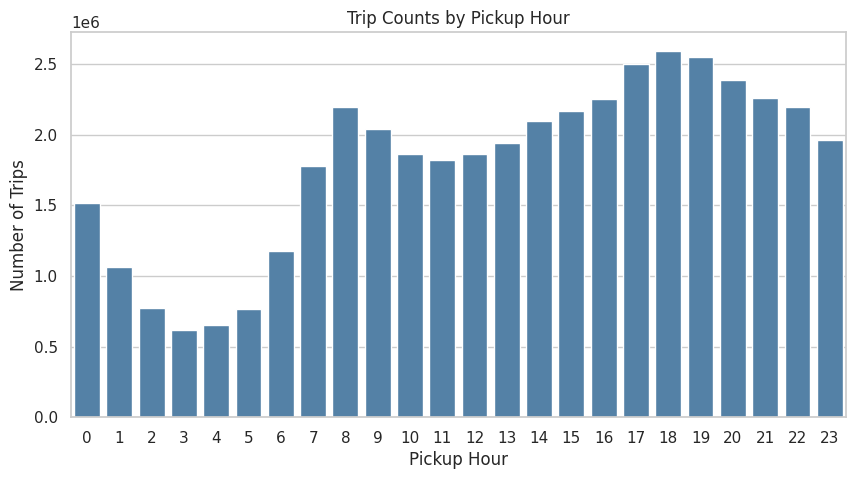

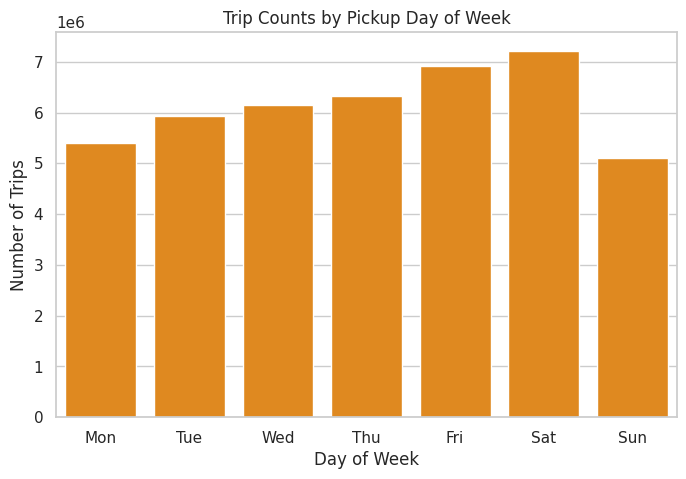

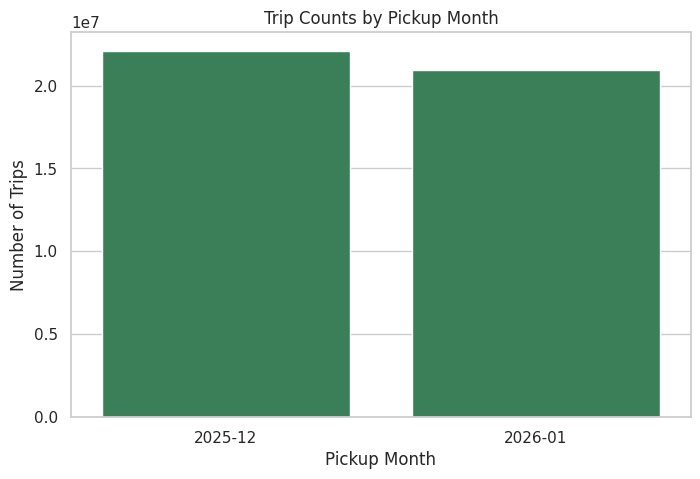

In [ ]:
# Hour-of-day distribution
hour_counts = df["pickup_hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=hour_counts.index.astype(str), y=hour_counts.values, color="steelblue")
plt.title("Trip Counts by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.show()


# Day-of-week distribution
day_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

day_counts = df["pickup_dayofweek"].value_counts().sort_index()
day_labels = [day_map.get(i, str(i)) for i in day_counts.index]

plt.figure(figsize=(8, 5))
sns.barplot(x=day_labels, y=day_counts.values, color="darkorange")
plt.title("Trip Counts by Pickup Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.show()


# Month distribution
month_counts = df["pickup_month"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=month_counts.index.astype(str), y=month_counts.values, color="seagreen")
plt.title("Trip Counts by Pickup Month")
plt.xlabel("Pickup Month")
plt.ylabel("Number of Trips")
plt.show()



The temporal summaries show clear structure in ride-share trip activity across the full cleaned dataset.

At the hourly level, trip counts are lowest during the early morning hours, especially around 3-4 AM, and then increase sharply after the morning commute period. Demand remains relatively high throughout the afternoon and reaches its strongest levels in the late afternoon and early evening, with the highest trip volumes occurring around 6-7 PM. This pattern is consistent with typical urban ride-share usage, where demand is concentrated around commuting, evening travel, and post-work activity.

At the day-of-week level, trip volume gradually increases from Monday through Saturday, with Saturday showing the highest number of trips. Sunday is lower than Friday and Saturday, suggesting a weekly pattern in which ride-share demand is strongest toward the end of the week.

At the month level, the total trip counts for December 2025 and January 2026 are relatively similar, although December is slightly higher in the current dataset. This suggests that the two-month data window is reasonably balanced and suitable for large-scale project analysis.

Overall, these temporal patterns indicate that trip demand is systematically shaped by time. Even though the baseline model in this notebook focuses only on `trip_miles`, the temporal structure identified here provides useful context for later stages of the project, especially feature engineering and more advanced modeling.


## Provider-Level Comparison

To provide additional context for the baseline supervised relationship, the dataset is also examined by provider using `hvfhs_license_num`.

This comparison helps assess whether the main trip and pay patterns are broadly consistent across providers or whether substantial provider-level differences are present in the cleaned dataset.


trip_miles           trip_time        driver_pay       
                    mean median         mean median       mean median
provider_name                                                        
Lyft            4.550007   2.66  1142.358195  931.0  19.563988  14.80
Uber            4.822354   2.79  1171.277162  944.0  21.039297  15.74

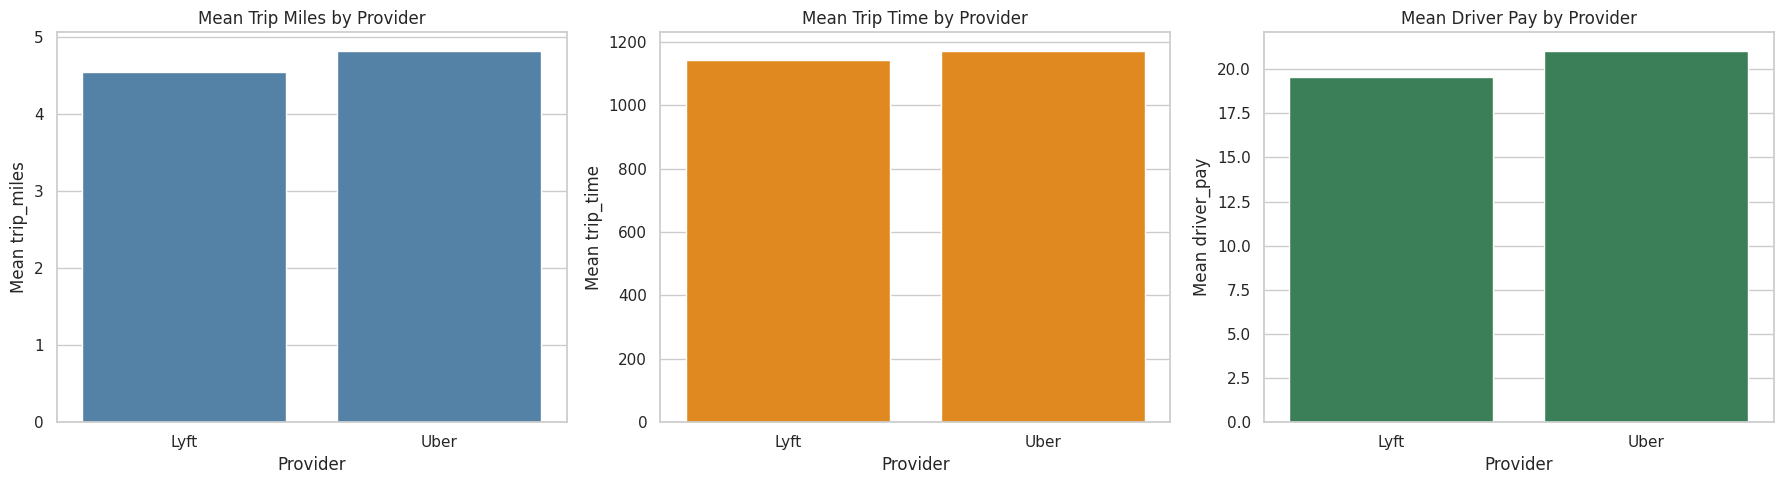

In [ ]:
provider_summary = (
    df.groupby("provider_name")[["trip_miles", "trip_time", "driver_pay"]]
      .agg(["mean", "median"])
)

display(provider_summary)

provider_means = (
    df.groupby("provider_name")[["trip_miles", "trip_time", "driver_pay"]]
      .mean()
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=provider_means, x="provider_name", y="trip_miles", ax=axes[0], color="steelblue")
axes[0].set_title("Mean Trip Miles by Provider")
axes[0].set_xlabel("Provider")
axes[0].set_ylabel("Mean trip_miles")

sns.barplot(data=provider_means, x="provider_name", y="trip_time", ax=axes[1], color="darkorange")
axes[1].set_title("Mean Trip Time by Provider")
axes[1].set_xlabel("Provider")
axes[1].set_ylabel("Mean trip_time")

sns.barplot(data=provider_means, x="provider_name", y="driver_pay", ax=axes[2], color="seagreen")
axes[2].set_title("Mean Driver Pay by Provider")
axes[2].set_xlabel("Provider")
axes[2].set_ylabel("Mean driver_pay")

plt.tight_layout()
plt.show()


The provider-level comparison shows that Uber and Lyft have broadly similar trip and pay structures in the full cleaned dataset, although Uber is consistently slightly higher on the main summary measures.

Uber has a higher mean trip distance (`4.82` miles vs `4.55` miles), a slightly higher median trip distance (`2.79` vs `2.66`), a slightly higher mean trip time (`1171.28` seconds vs `1142.36`), and a slightly higher mean and median `driver_pay` (`21.04` and `15.74`) than Lyft (`19.56` and `14.80`).

These differences suggest that provider-level variation exists, but the overall magnitudes are not dramatically different. This supports the interpretation that the baseline relationship between `trip_miles` and `driver_pay` reflects a broad pattern in the cleaned dataset rather than being driven entirely by one provider. At the same time, the provider differences indicate that platform-level operational factors may also contribute to driver earnings and should be kept in mind when interpreting later modeling results.


## Distribution of Key Variables

Before fitting a baseline supervised model, it is important to examine the distributions of the main variables of interest.

This section focuses on:
- `trip_miles`, the baseline input feature,
- `driver_pay`, the target variable.

Understanding these distributions helps assess skewness, concentration of values, and the presence of extreme observations that may influence model interpretation.


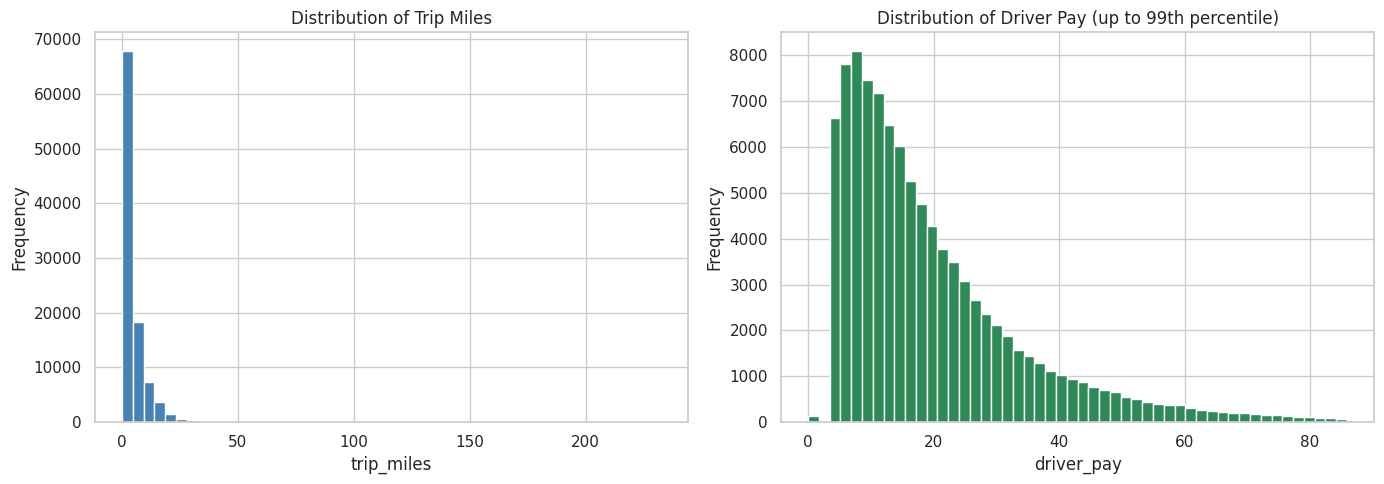

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_viz["trip_miles"].dropna(), bins=50, color="steelblue")
axes[0].set_title("Distribution of Trip Miles")
axes[0].set_xlabel("trip_miles")
axes[0].set_ylabel("Frequency")

upper_pay = df_viz["driver_pay"].quantile(0.99)
axes[1].hist(
    df_viz.loc[df_viz["driver_pay"] <= upper_pay, "driver_pay"].dropna(),
    bins=50,
    color="seagreen"
)
axes[1].set_title("Distribution of Driver Pay (up to 99th percentile)")
axes[1].set_xlabel("driver_pay")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


The distributions of both `trip_miles` and `driver_pay` are strongly right-skewed.

For `trip_miles`, most observations are concentrated at relatively low values, showing that the dataset is dominated by short trips, while a much smaller number of observations extend far into the upper tail. This is consistent with the structure of urban ride-share travel, where short-distance trips are much more common than very long rides.

For `driver_pay`, the distribution is also concentrated in lower-to-moderate ranges, with a long right tail indicating that a smaller number of trips generate much higher earnings. The plot is shown up to the 99th percentile to improve readability while still preserving the main shape of the distribution.

These results suggest that both the baseline predictor (`trip_miles`) and the target variable (`driver_pay`) are non-uniformly distributed and contain extreme observations. This is important for interpreting later model behavior and motivates further examination of the relationship between distance and earnings.


### Raw vs Log-Transformed Distributions

Because both `trip_miles` and `driver_pay` are strongly right-skewed, a comparison between the raw and log-transformed versions is included.

The purpose of this comparison is to show how log transformation compresses the long upper tails and produces more compact distributions. This is useful for understanding the structure of the data and for motivating later project stages in which richer preprocessing and feature engineering may be applied.


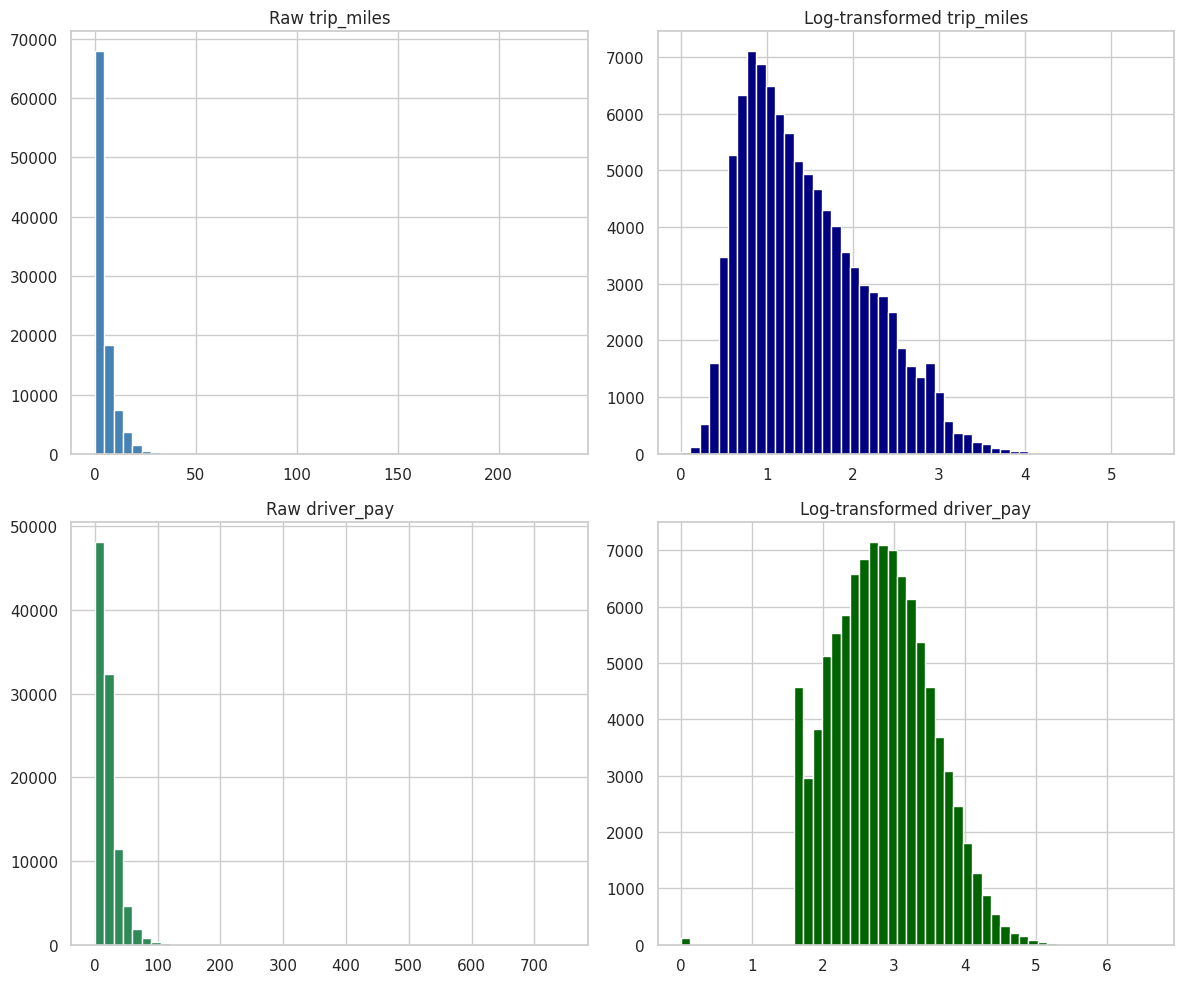

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(df_viz["trip_miles"].dropna(), bins=50, color="steelblue")
axes[0, 0].set_title("Raw trip_miles")

axes[0, 1].hist(np.log1p(df_viz["trip_miles"].dropna()), bins=50, color="navy")
axes[0, 1].set_title("Log-transformed trip_miles")

axes[1, 0].hist(df_viz["driver_pay"].dropna(), bins=50, color="seagreen")
axes[1, 0].set_title("Raw driver_pay")

driver_pay_clipped = np.clip(df_viz["driver_pay"].dropna(), a_min=0, a_max=None)
axes[1, 1].hist(np.log1p(driver_pay_clipped), bins=50, color="darkgreen")
axes[1, 1].set_title("Log-transformed driver_pay")

plt.tight_layout()
plt.show()


The raw-versus-log comparison shows that log transformation substantially reduces skewness in both variables. In particular, the long right tails become more compressed and the overall distributions become easier to compare visually.

This does not change the role of the simple linear baseline model used in this notebook, but it provides useful context for later project stages where transformed variables or engineered features may help improve modeling performance.


## Bivariate Analysis: Trip Miles vs Driver Pay

After examining the marginal distributions of the main variables, the next step is to study their joint relationship.

This section focuses on the relationship between `trip_miles` and `driver_pay`, which is the central supervised relationship in the baseline model. A scatter plot is used to assess whether the relationship appears approximately linear and whether any obvious dispersion patterns or outliers are present.


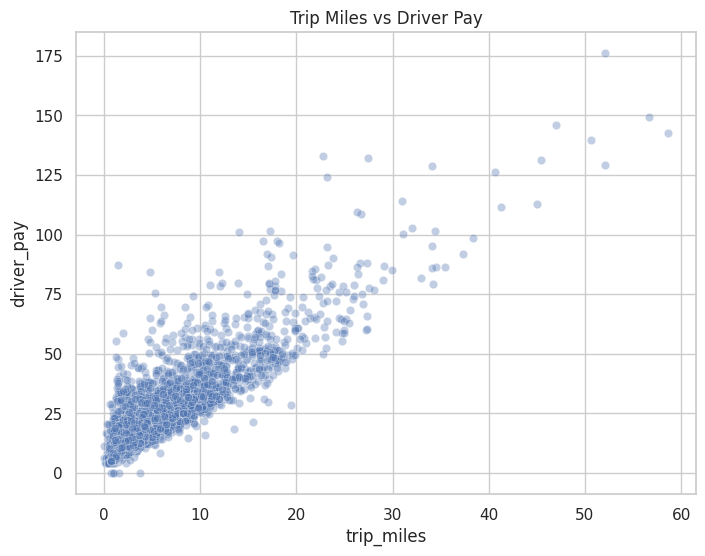

In [ ]:
scatter_n = min(5000, len(df_viz))
scatter_df = df_viz.sample(n=scatter_n, random_state=42) if len(df_viz) > scatter_n else df_viz.copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=scatter_df,
    x="trip_miles",
    y="driver_pay",
    alpha=0.35
)
plt.title("Trip Miles vs Driver Pay")
plt.xlabel("trip_miles")
plt.ylabel("driver_pay")
plt.show()


The scatter plot shows a clear positive relationship between `trip_miles` and `driver_pay`. In general, trips with greater distance are associated with higher driver earnings, which supports the use of distance as a baseline predictor.

At the same time, the plot also shows visible dispersion around the overall trend. This suggests that although distance is an important predictor, it does not explain all of the variation in driver pay. In addition, the spread of `driver_pay` tends to increase at larger trip distances, indicating that the relationship may involve heteroscedasticity and other sources of variation not captured by a simple linear baseline.

Overall, the upward trend supports the use of linear regression as a first benchmark, while also motivating the need for richer features and more advanced supervised models in later stages of the project.


## Correlation Analysis

To quantify the strength of the relationship between `trip_miles` and `driver_pay`, the Pearson correlation coefficient is computed.

This provides a simple numerical summary of the linear association and helps support the interpretation of the baseline supervised modeling stage.


In [ ]:
corr_matrix = df_viz[["trip_miles", "driver_pay"]].corr()
display(corr_matrix)

corr_value = corr_matrix.loc["trip_miles", "driver_pay"]
print("Pearson correlation coefficient:", round(corr_value, 4))
print("Approximate R^2 from correlation:", round(corr_value**2, 4))


,trip_miles,driver_pay
trip_miles,1.000000,0.898949
driver_pay,0.898949,1.000000


Pearson correlation coefficient: 0.8989
Approximate R^2 from correlation: 0.8081


The Pearson correlation coefficient between `trip_miles` and `driver_pay` is **0.8989**, indicating a very strong positive linear relationship.

An approximate coefficient of determination can be obtained as:

`R² ≈ (0.8989)² ≈ 0.8081`

This suggests that roughly 81% of the variation in `driver_pay` can be explained by a linear relationship with trip distance alone.

While correlation does not imply causation, the strength of this association strongly supports the use of `trip_miles` as the predictor in the baseline linear regression model. At the same time, the remaining unexplained variation suggests that additional trip and contextual features may improve performance in later supervised models.


## Baseline Supervised Modeling

A simple linear regression model is used as the baseline supervised model.

The baseline uses:
- input feature: `trip_miles`
- target variable: `driver_pay`

This model is intentionally simple and interpretable. Its purpose is to establish a benchmark for later comparison with more advanced supervised learning models.

### Defining Features and Target

To establish the baseline model, `trip_miles` is used as the single predictor and `driver_pay` is used as the response variable.

This setup directly corresponds to the main supervised research question of the notebook: whether trip distance alone provides a useful first-order prediction of driver earnings.


In [ ]:
model_df = df[["trip_miles", "driver_pay"]].dropna().copy()

if model_df.empty:
    raise ValueError("No valid rows available for baseline modeling.")

X = model_df[["trip_miles"]]
y = model_df["driver_pay"]

print("Modeling dataframe shape:", model_df.shape)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(model_df.head())


Modeling dataframe shape: (43043669, 2)
Feature shape: (43043669, 1)
Target shape: (43043669,)


,trip_miles,driver_pay
0,8.780,30.370001
1,4.528,12.830000
2,12.670,34.669998
3,8.748,32.820000
4,2.376,10.700000


### Train / Validation / Test Split

To evaluate the baseline model in a consistent way, the data is divided into three parts:

- 70% training set
- 15% validation set
- 15% test set

The training set is used to fit the linear regression model. The validation set is used to assess intermediate performance, and the test set is reserved for final evaluation on unseen data.

This split supports a more reliable assessment of generalization performance than evaluating the model on the training data alone.


In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y, random_state=42)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")


Train shape: (30130568, 1) (30130568,)
Validation shape: (6456550, 1) (6456550,)
Test shape: (6456551, 1) (6456551,)
Train: 30130568 (70.0%)
Validation: 6456550 (15.0%)
Test: 6456551 (15.0%)


### Linear Regression Model

A simple linear regression model is now fitted using `trip_miles` as the predictor and `driver_pay` as the response variable.

Because the model uses only a single feature, it remains highly interpretable. The fitted intercept and slope provide a direct summary of the baseline relationship between trip distance and driver pay.


In [ ]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

intercept = baseline_model.intercept_
slope = baseline_model.coef_[0]

print("Intercept:", round(intercept, 4))
print("Slope:", round(slope, 4))
print(f"Fitted equation: driver_pay = {intercept:.3f} + {slope:.3f} * trip_miles")


Intercept: 7.242
Slope: 2.8208
Fitted equation: driver_pay = 7.242 + 2.821 * trip_miles


The fitted linear regression model can be interpreted as:

`driver_pay = 7.242 + 2.821 × trip_miles`

The intercept (`7.242`) represents the estimated baseline level of driver pay when trip distance is zero. Although a zero-mile trip is not practically meaningful in most ride-share settings, the intercept can still be interpreted as capturing the fixed component of compensation in the linear model.

The slope (`2.821`) indicates that, on average, `driver_pay` is expected to increase by about **$2.82** for each additional mile traveled. This positive slope is consistent with the earlier EDA and correlation analysis, both of which showed a strong positive relationship between trip distance and driver earnings.

This baseline model is intentionally simple, but it provides an interpretable benchmark for later comparison with more advanced supervised learning models.


## Comprehensive Evaluation

The baseline model is evaluated on the training, validation, and test sets using standard regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

Reporting results across all three splits helps assess both goodness of fit and generalization performance.


In [ ]:
train_pred = baseline_model.predict(X_train)
val_pred = baseline_model.predict(X_val)
test_pred = baseline_model.predict(X_test)

train_metrics = regression_metrics(y_train, train_pred)
train_metrics["Split"] = "Train"

val_metrics = regression_metrics(y_val, val_pred)
val_metrics["Split"] = "Validation"

test_metrics = regression_metrics(y_test, test_pred)
test_metrics["Split"] = "Test"

results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
display(results_df.round(4))


,MAE,MSE,RMSE,R2,Split
0,5.1231,63.8439,7.9902,0.8010,Train
1,5.1208,62.1817,7.8855,0.8051,Validation
2,5.1232,62.3973,7.8992,0.8052,Test


### Evaluation Results Interpretation

The baseline model performs consistently across the training, validation, and test sets.

On the test set, the model achieves:
- **MAE = 5.1232**
- **MSE = 62.3973**
- **RMSE = 7.8992**
- **R² = 0.8052**

These results indicate that the simple linear regression baseline captures a substantial share of the variation in `driver_pay`, with an `R²` of approximately `0.81` on both the validation and test sets.

The similarity of the training, validation, and test metrics suggests that the model generalizes reasonably well and is not strongly overfitting. At the same time, the prediction error remains nontrivial, which indicates that trip distance alone is not sufficient to fully explain driver earnings. This supports the need for later stages of the project that incorporate richer features and more advanced supervised learning models.


### Actual vs Predicted Values on the Test Set

To complement the numerical metrics, the relationship between actual and predicted `driver_pay` values is visualized on the test set.

If the model performs well, the points should lie relatively close to the 45-degree reference line. Deviations from that line indicate prediction error and help illustrate where the baseline model is less accurate.


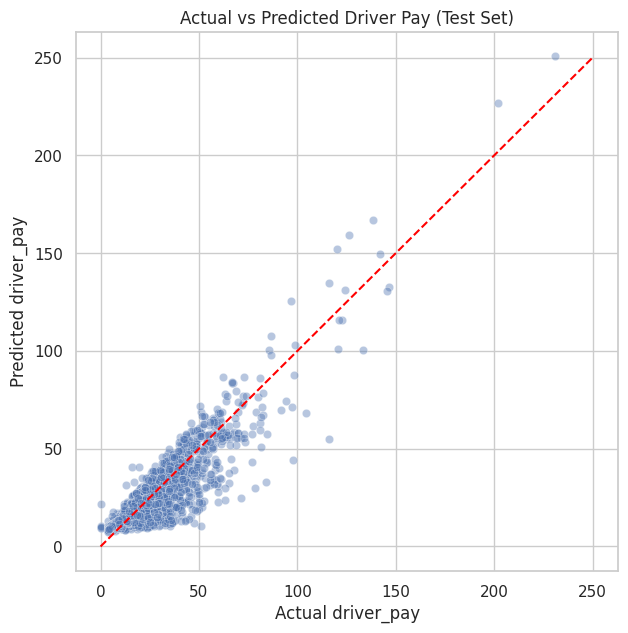

In [ ]:
test_plot_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_pred
})

plot_n = min(3000, len(test_plot_df))
test_plot_df = test_plot_df.sample(n=plot_n, random_state=42) if len(test_plot_df) > plot_n else test_plot_df.copy()

plt.figure(figsize=(7, 7))
sns.scatterplot(data=test_plot_df, x="Actual", y="Predicted", alpha=0.4)

lims = [
    min(test_plot_df["Actual"].min(), test_plot_df["Predicted"].min()),
    max(test_plot_df["Actual"].max(), test_plot_df["Predicted"].max())
]
plt.plot(lims, lims, color="red", linestyle="--")

plt.title("Actual vs Predicted Driver Pay (Test Set)")
plt.xlabel("Actual driver_pay")
plt.ylabel("Predicted driver_pay")
plt.show()


The actual-versus-predicted plot shows that the baseline model captures the general upward structure of the target reasonably well, with many observations falling near the 45-degree reference line.

However, the spread around the line also confirms that prediction error remains substantial for individual trips. In particular, the model tends to be less precise for observations farther from the center of the distribution, which is consistent with the earlier finding that trip distance alone does not fully explain `driver_pay`.

This visualization supports the numerical evaluation results: the baseline model provides a strong first benchmark, but there is still meaningful room for improvement through richer features and more advanced models.


### Residual Distribution

A residual plot is used to examine the distribution of prediction errors on the test set.

Residuals are defined as:

`residual = actual - predicted`

If the model is well behaved, residuals should be centered around zero without strong systematic bias. The spread of the residuals provides additional context beyond the numerical metrics alone.


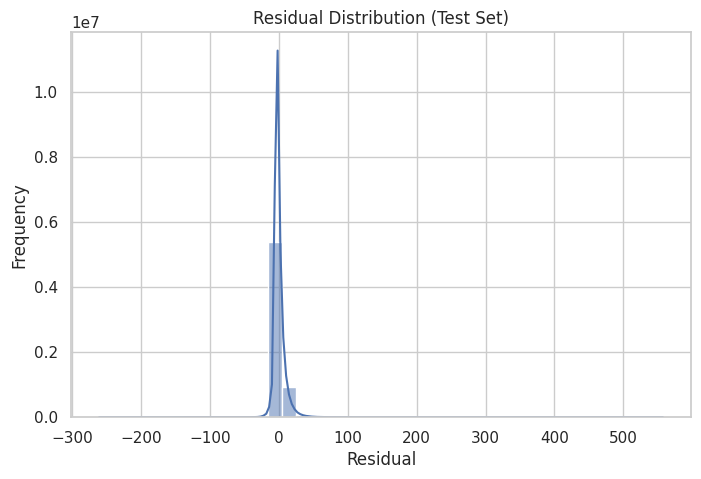

In [ ]:
residuals = y_test.values - test_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution (Test Set)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


The residual distribution is centered broadly around zero, which suggests that the baseline model does not exhibit a strong overall tendency to systematically overpredict or underpredict driver pay across the full test set.

At the same time, the residual spread is substantial, indicating that individual trip-level prediction errors remain meaningful. This is consistent with the earlier EDA and evaluation results: while `trip_miles` is a strong predictor, it does not capture all of the factors that influence driver earnings.

Taken together, the residual distribution reinforces the role of the linear regression model as a useful baseline benchmark rather than a final predictive solution.


### Regression Line Visualization

To make the baseline supervised relationship more explicit, the fitted linear regression line is overlaid on a sample of the observed data.

This plot helps visualize how the baseline model summarizes the overall trend between `trip_miles` and `driver_pay`.


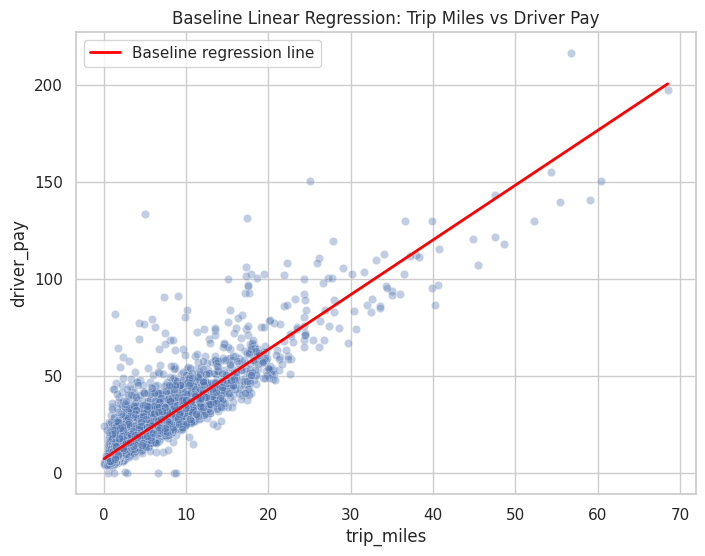

In [ ]:
line_n = min(5000, len(model_df))
line_df = model_df.sample(n=line_n, random_state=42) if len(model_df) > line_n else model_df.copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=line_df, x="trip_miles", y="driver_pay", alpha=0.35)

x_line = np.linspace(line_df["trip_miles"].min(), line_df["trip_miles"].max(), 200)
y_line = baseline_model.intercept_ + baseline_model.coef_[0] * x_line
plt.plot(x_line, y_line, color="red", linewidth=2, label="Baseline regression line")

plt.title("Baseline Linear Regression: Trip Miles vs Driver Pay")
plt.xlabel("trip_miles")
plt.ylabel("driver_pay")
plt.legend()
plt.show()


The regression line captures the overall upward trend between trip distance and driver pay, which is consistent with the strong positive correlation identified earlier.

The figure also makes clear that the observed data points do not fall exactly on the fitted line. This reinforces the interpretation that `trip_miles` is an important predictor, but not a complete explanation of `driver_pay`.

As a result, the regression line serves as a useful visual summary of the baseline relationship while also highlighting the limitations of a single-feature linear model.


## Limitations

This baseline analysis has several limitations.

First, the model uses only `trip_miles` as a predictor and therefore cannot capture many other factors that may influence `driver_pay`, such as trip duration, time of day, pricing rules, traffic conditions, platform-level variation, and other operational effects.

Second, although the baseline model performs reasonably well, the evaluation results and residual distribution show that substantial variation remains unexplained. This means that distance alone is not sufficient to fully model driver earnings at the trip level.

Third, the strong linear relationship observed between `trip_miles` and `driver_pay` should not be interpreted as causal. It provides a useful predictive benchmark, but it does not establish that trip distance is the only or underlying cause of changes in driver pay.

For these reasons, the linear regression model in this notebook should be interpreted as an informative baseline benchmark rather than a final predictive solution.


## Connection to Later Pipeline Stages

This notebook supports the later stages of the final project pipeline in two ways.

First, the baseline linear regression model provides a clear and interpretable benchmark against which later advanced supervised learning models can be compared.

Second, the EDA results highlight important structural properties of the data, including skewed variable distributions, temporal demand patterns, and modest provider-level differences. These findings help motivate later stages of the project that incorporate richer feature engineering, unsupervised learning, and more advanced predictive models.


## Conclusion

This notebook established the Exploratory Data Analysis (EDA) and baseline supervised modeling component of the final project pipeline.

The analysis showed that `trip_miles` is strongly associated with `driver_pay`, and the baseline linear regression model provides a useful interpretable benchmark with reasonably stable performance across the training, validation, and test sets.

At the same time, the remaining prediction error and residual spread show that trip distance alone does not fully explain driver earnings. This motivates the later stages of the project, where more sophisticated modeling approaches and additional features are used to improve predictive performance and deepen interpretation.
